## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

### Name: Tanim Choudhury

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis
The purpose of this analysis is produce an analytical solution for Blue Ridge Filament Co(BRFC) to determine if their Extruder Line 3 exhbits statistical control.
### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.
The quality characteristic we will monitor is Filament Diameter which is in mm. For measurement scale, it is a continous variable and has a true zero value, so ratio would make the most sense here.
### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?
From context, we see that the filament diameter is continous & follows a normal distribution. Which X bar & R chart are designed for. We are using X bar to see if the mean is staying where suppose to be(1.750 mm). One limitation is that skewing causes the chart to perform reliably.  
## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.


In [1]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "tchoud227"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

# Change the working directory to the specific assignment folder within the cloned repository
setwd(file.path(repo_name, "Assignments", "HW1"))

In [2]:
getwd()

[1] "/content/STAT-7110-Quality-Control/Assignments/HW1"

In [3]:
install.packages(c("tidyverse", "readxl", "qcc"))

library(tidyverse)
library(readxl)
library(qcc)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



In [4]:
## Q4 Code ##
filamentP1_df <- read_excel("FilamentDiameter_PhaseI.xlsx")

filamentP1_df |> glimpse()


## Process mean & std with both r & s method ##
#constants from MIT table with n = 5
d2 <- 2.326
c4 <- 0.9400

#remove subgroup
filamentP1_df <- filamentP1_df |> select(-"Subgroup")

week_stats <- filamentP1_df |>
  mutate(
      xbar = rowMeans(filamentP1_df),
      r = apply(filamentP1_df, 1, function(x) max(x) - min(x)),
      s = apply(filamentP1_df, 1, sd)
)

xDouble_bar <- mean(week_stats$xbar)
rBar <- mean(week_stats$r)
sBar <- mean(week_stats$s)

#estimate unknown parameters
mu <- xDouble_bar
rSigma <- rBar/ d2
sSigma <- sBar/ c4

print(mu)
print(rSigma)
print(sSigma)





Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…
[1] 1.754017
[1] 0.01144864
[1] 0.01154467


From this estimation, the mean appears to algin with the target diameter. There is a slight positive skew. The std for both methods are also neck to neck which shows promise.


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

In [5]:
## Q5 Code ##

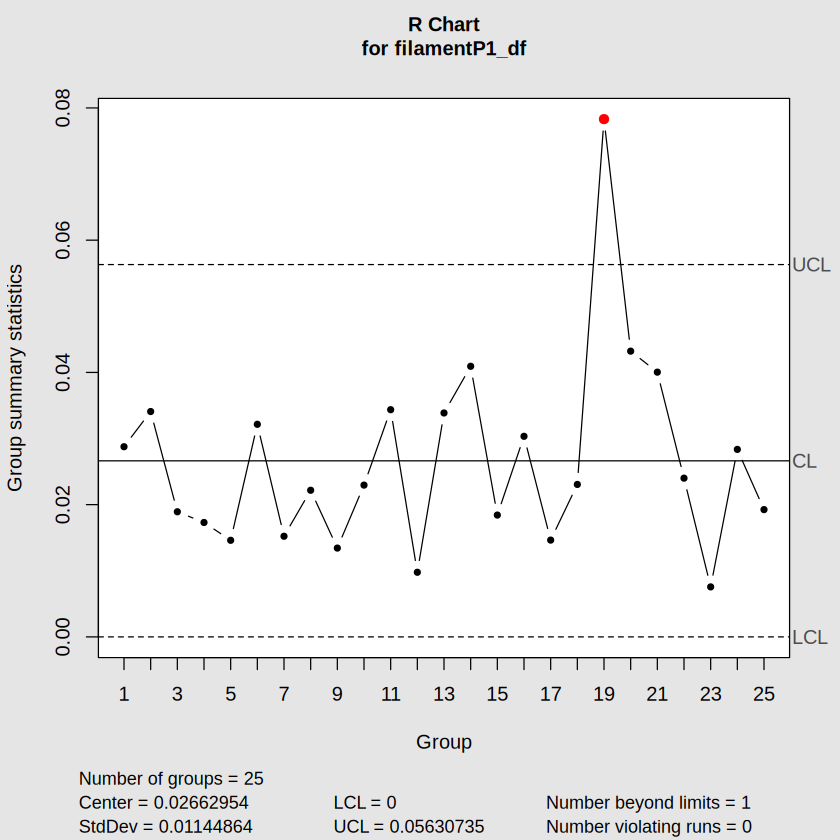

In [6]:
# R chart
# note already removed the sub group column
phase1_r <- qcc(filamentP1_df,
                   type = "R",
                   plot = TRUE)

No evidence, because week 19 is past the upper control limit. This could possibly because of the line's 3 heating element which was noted to be 6 months away for need of replacement. Another possibility is potential issue with mechanical source such as clogging.

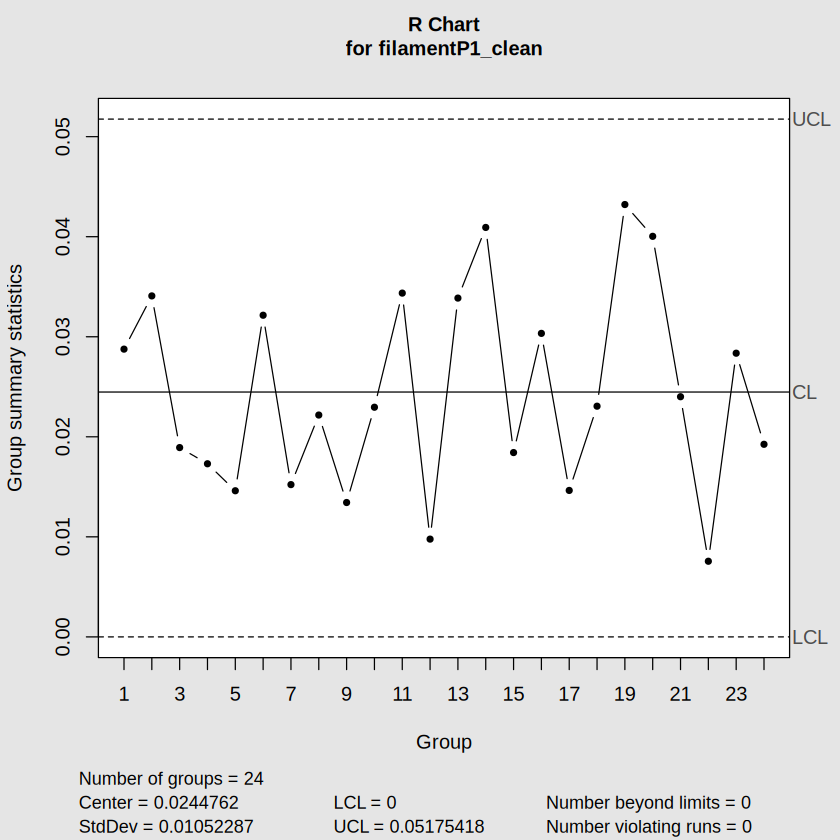

In [7]:
# Ommitting week19
filamentP1_clean <- filamentP1_df |> slice(-19)
phase1_r_clean <- qcc(filamentP1_clean,
                      type = "R",
                      plot = TRUE)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

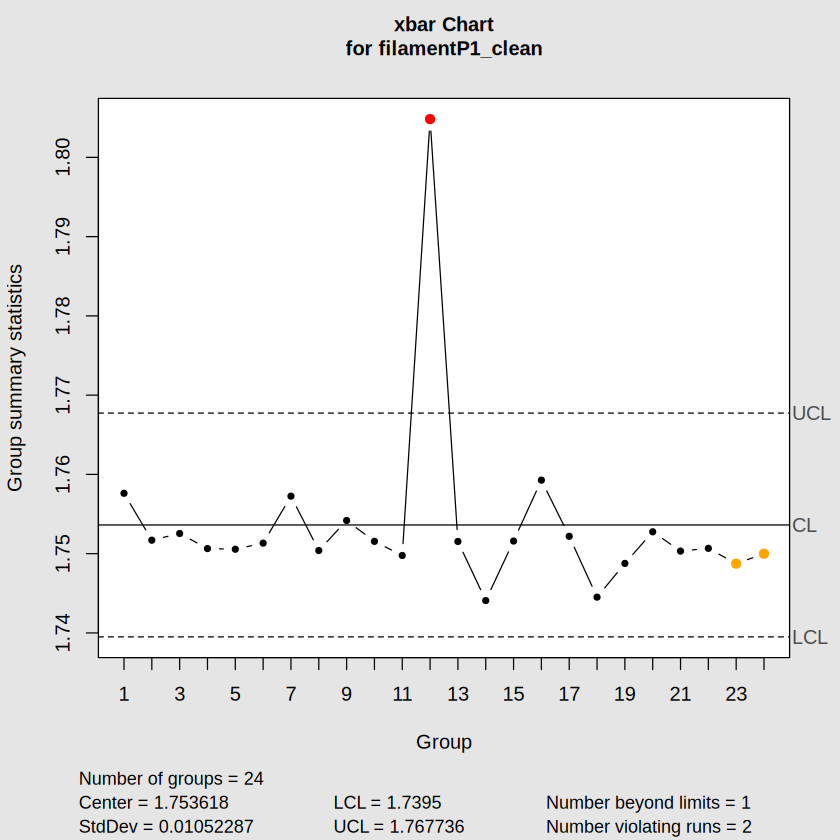

In [8]:
## Q6 Code ##
phase1_xbar <- qcc(filamentP1_clean,
                   type = "xbar",
                   plot = TRUE)


No evidence of statistical control, week 12 exceeds the UCL. There also appears to be some violating runs as well. These OOC points may be because of the heating element not working as attended.  

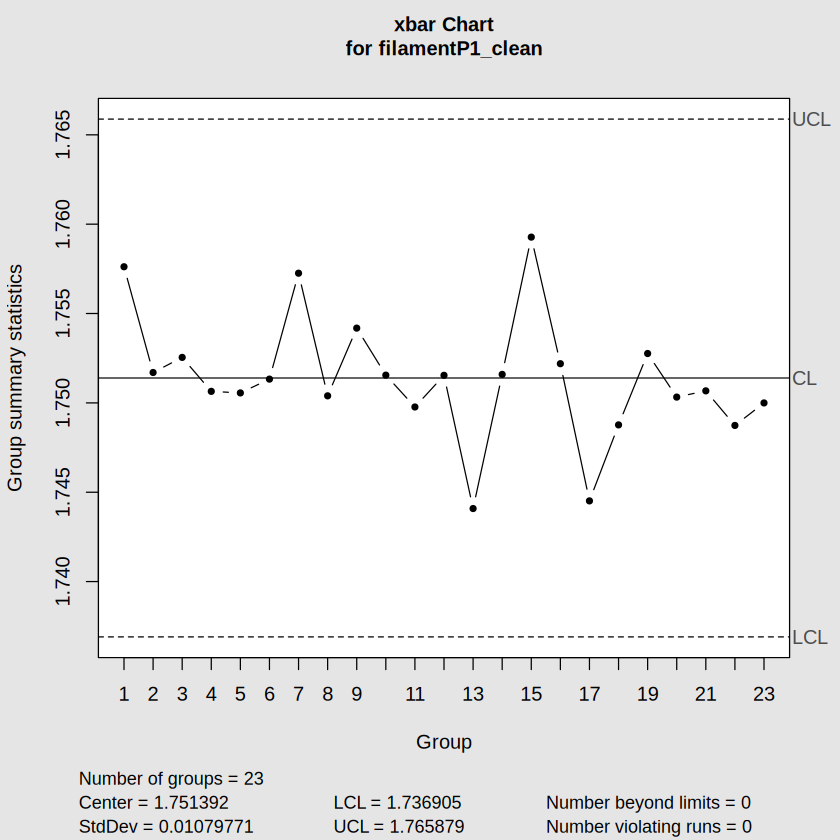

In [9]:
# Ommitting week12
filamentP1_clean <- filamentP1_clean |> slice(-12)
phase1_xbar_clean <- qcc(filamentP1_clean,
                      type = "xbar",
                      plot = TRUE)

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

[1] 0.01154467


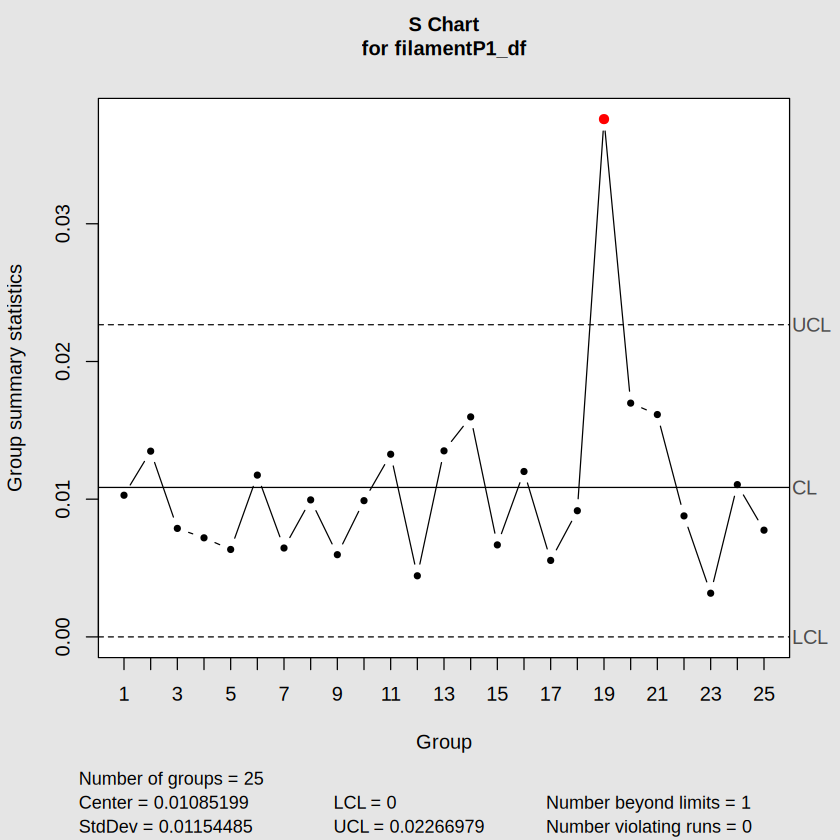

In [10]:
## Q7 Code ##
# for question 4 I already calculated sSigma earlier.
print(sSigma)
# s chart
phase1_s <- qcc(filamentP1_df,
                   type = "S",
                   plot = TRUE)

We again see that week 19 is violating statistical control

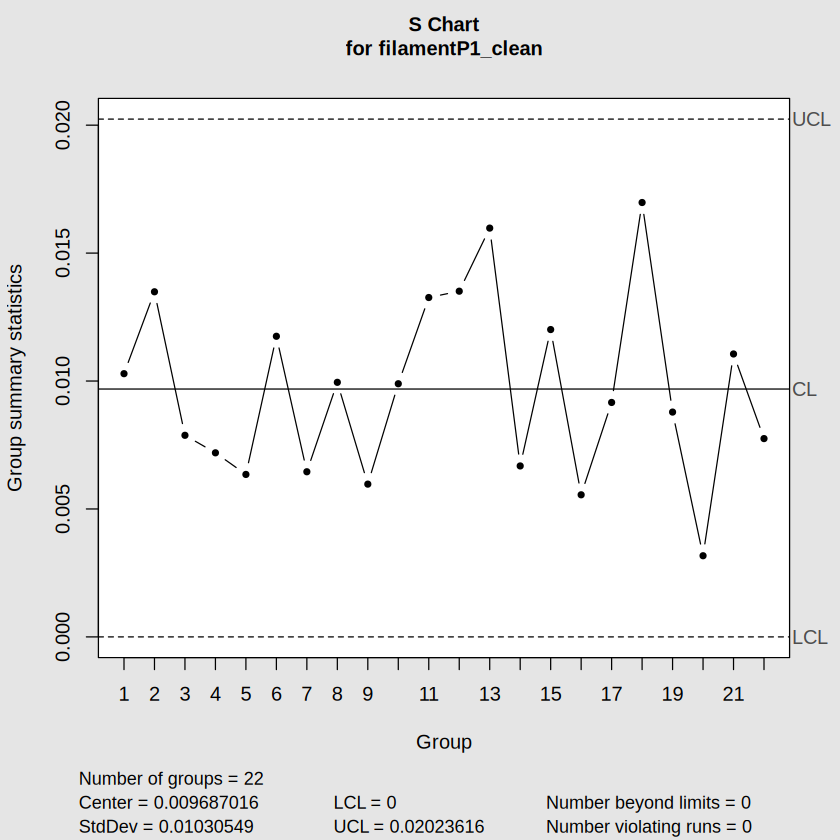

In [11]:
# Ommitting week19
filamentP1_clean <- filamentP1_clean |> slice(-19)
phase1_s_clean <- qcc(filamentP1_clean,
                      type = "S",
                      plot = TRUE)

No violations!

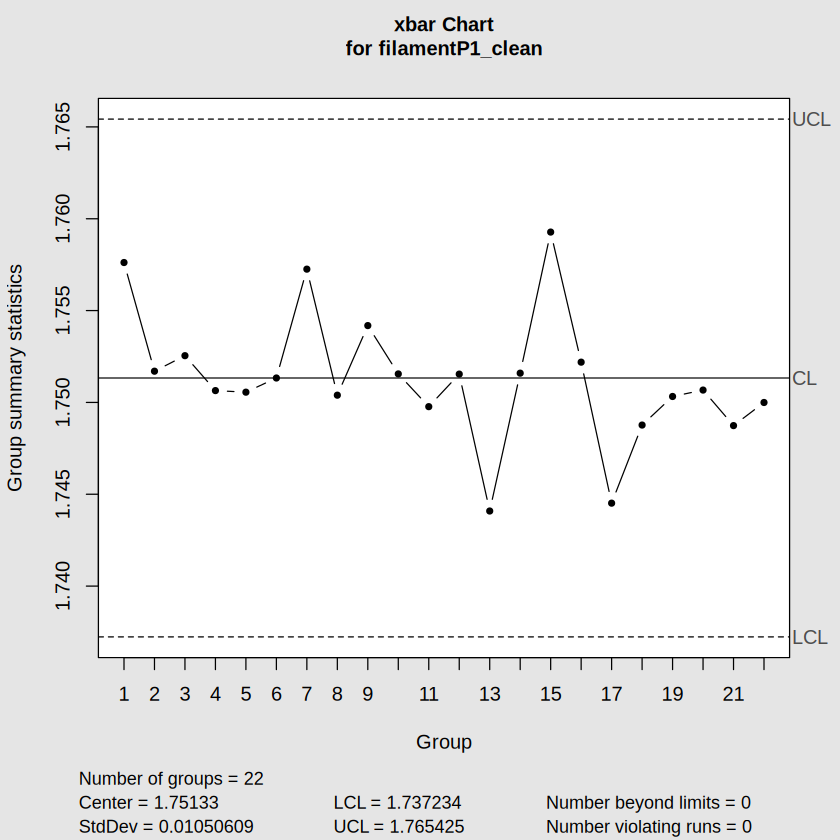

In [12]:
#xbar
phase1_xbar <- qcc(filamentP1_clean,
                   type = "xbar",
                   plot = TRUE)

No violations!

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [13]:
## Q8 Code ##
# From Key specifications
Target <- 1.75
LSL <- 1.70
USL <- 1.80

#Parameter estimate from s
mu <- phase1_xbar$center
sigma <- phase1_s_clean$std.dev

#FNC
FNC_L <- pnorm(LSL, mu, sigma)
FNC_U <- pnorm(USL, mu, sigma, lower.tail = FALSE)
FNC <- FNC_L + FNC_U

#Cp
cp <- (USL - LSL) / (6 * sigma)

#cpk
cpl <- (mu - LSL) / (3 * sigma)
cpu <- (USL - mu) / (3 * sigma)
cpk <- min(cpl, cpu)

#cpm
cpm <- (mu - Target) / (6 * sqrt(sigma^2 + (mu - Target)^2))

print(FNC)
print(cp)
print(cpk)
print(cpm)



[1] 1.479997e-06
[1] 1.61726
[1] 1.574248
[1] 0.02132927


For FNC, we a value near 0% value which is ideal. For cp, we have the value 1.61 which is > 1 which means the process is capable. For cpk, we can see the value is 1.57 which is > 1 which means the process is capable. Finally for cpm, we have a value greater than 1 which shows the process is near the target. Overall, this process is capable meeting specification & well centered.

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

It is not advisble to leave the OOC points as it would inflate process mean & standard devation. Specifically, the week 12 heating element temperature drop and week 19 uncalibrated mechanical parts would widen the upper & lower control limits away from the printer natural capabillities.

Rows: 20
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.741281, 1.752716, 1.757787, 1.750684, 1.750781, 1.746839, 1…
$ Meas2    <dbl> 1.755570, 1.752597, 1.749910, 1.739595, 1.750607, 1.758723, 1…
$ Meas3    <dbl> 1.754157, 1.748972, 1.755079, 1.747991, 1.750896, 1.751448, 1…
$ Meas4    <dbl> 1.754749, 1.749849, 1.747444, 1.749558, 1.754583, 1.752087, 1…
$ Meas5    <dbl> 1.733665, 1.745653, 1.756482, 1.756971, 1.750307, 1.744185, 1…


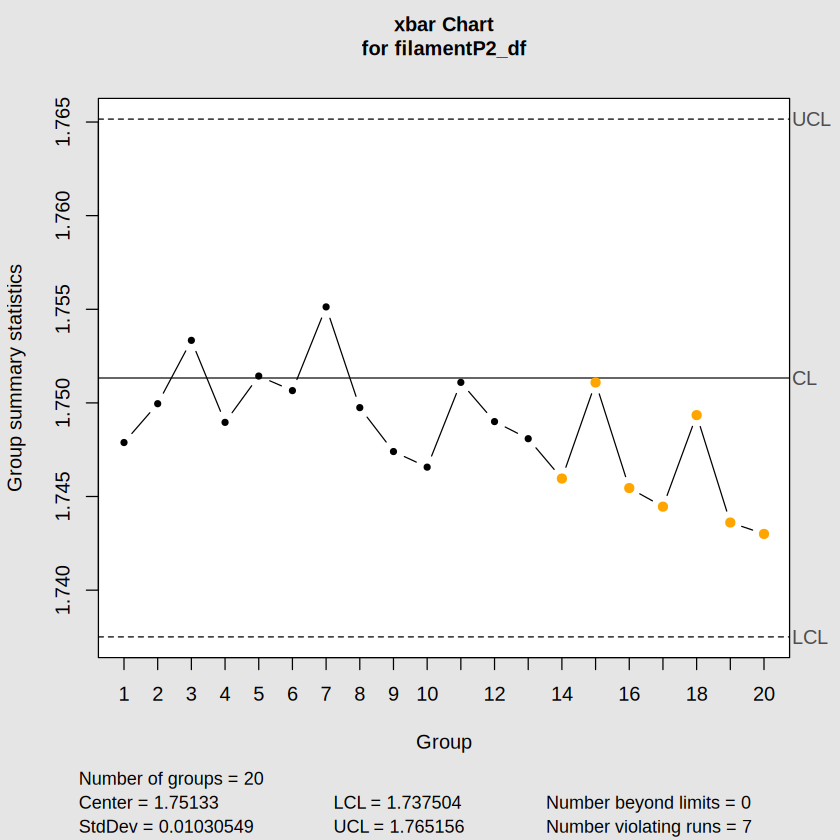

In [14]:
## Q10 Code ##
filamentP2_df <- read_excel("FilamentDiameter_PhaseII.xlsx")

filamentP2_df |> glimpse()

filamentP2_df <- filamentP2_df |> select(-"Subgroup")

phase2_xbar <- qcc(filamentP2_df,
                   type = "xbar",
                   center = mu,
                   std.dev = sigma,
                   plot = TRUE)

No subgroups plot are outside the limits but there are several violating runs.

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

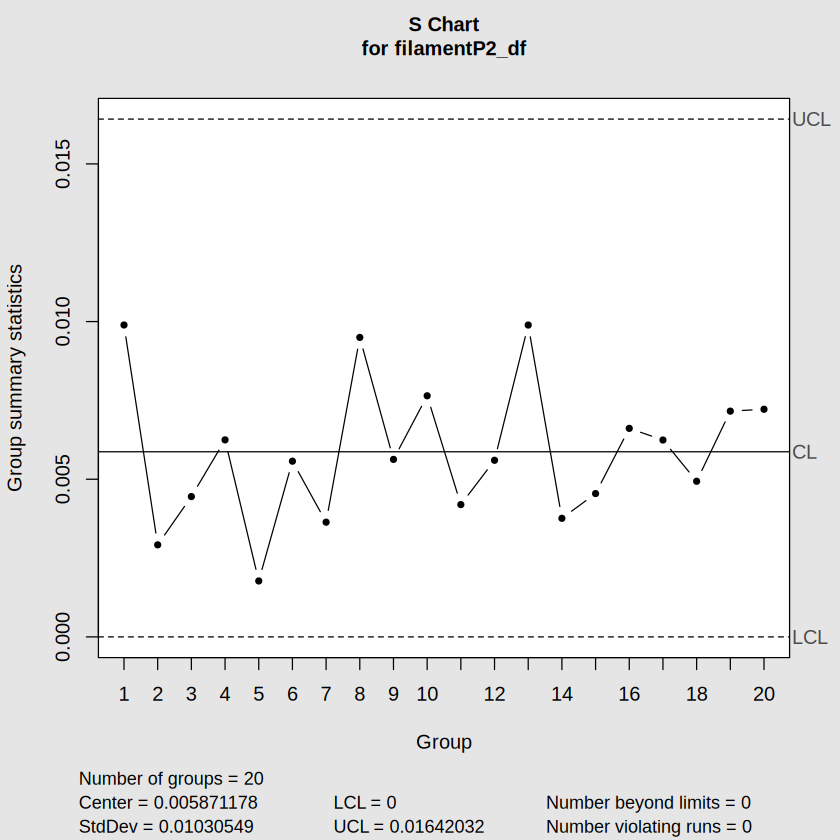

In [15]:
## Q11 Code ##
phase2_s_chart <- qcc(filamentP2_df,
                   type = "S",
                   std.dev = sigma,
                   plot = TRUE)

No subgroups are beyond the limits.

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

Overall, this report showcases that the printer is a capable process. First, we found it to be statistically stable(phase 1). Next, we observed common metrics for process capability(FNC, cp, cpk, & cpm) which found the machine to be statistically capable. Finally, we monitored data instead of just historical data and found it to be statistically stable and capable. From my findings in this report, line 3 is salvagable. The fix would be some sort maintenance of mechanical wear & tear & more frequent heating element diagnosis to determine need for replacement.